In [11]:
import re
import string
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
 
# Download required NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [13]:
CSV_PATH = "IMDB Dataset.csv"   # <-- change filename here if yours differs

print(f"Loading dataset from {CSV_PATH}...")
df = pd.read_csv(CSV_PATH)

# Rename 'review' → 'text' for consistency throughout the script
df.rename(columns={"review": "text"}, inplace=True)

# Encode label: positive=1, negative=0
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

# Sanity check
assert df["label"].isna().sum() == 0, "Unexpected sentiment values in dataset!"

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTraining samples : {len(train_df)}")
print(f"Test samples     : {len(test_df)}")
print(f"\nSample row:\n{train_df.iloc[0]}")


Loading dataset from IMDB Dataset.csv...

Training samples : 40000
Test samples     : 10000

Sample row:
text         I caught this little gem totally by accident b...
sentiment                                             positive
label                                                        1
Name: 0, dtype: object



===== EDA =====

Class Distribution (Train):
sentiment
positive    20000
negative    20000
Name: count, dtype: int64


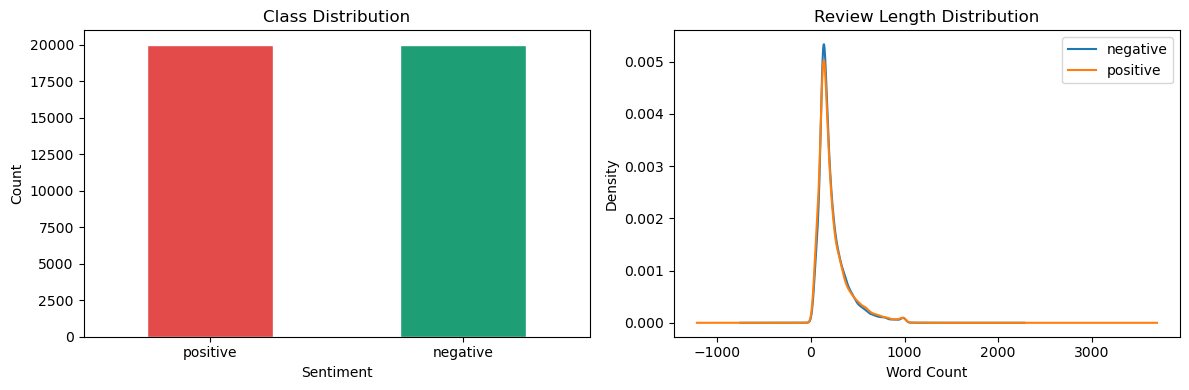

EDA plots saved to eda_plots.png

Average review length : 231 words
Max review length     : 2470 words
Min review length     : 4 words


In [14]:
def run_eda(train_df):
    print("\n===== EDA =====")

    # Class distribution
    print("\nClass Distribution (Train):")
    print(train_df["sentiment"].value_counts())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot 1: Class balance
    train_df["sentiment"].value_counts().plot(
        kind="bar", ax=axes[0], color=["#E24B4A", "#1D9E75"], edgecolor="white"
    )
    axes[0].set_title("Class Distribution")
    axes[0].set_xlabel("Sentiment")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis='x', rotation=0)

    # Plot 2: Review length distribution
    train_df["review_length"] = train_df["text"].apply(lambda x: len(x.split()))
    train_df.groupby("sentiment")["review_length"].plot(
        kind="kde", ax=axes[1], legend=True
    )
    axes[1].set_title("Review Length Distribution")
    axes[1].set_xlabel("Word Count")

    plt.tight_layout()
    plt.savefig("eda_plots.png", dpi=150)
    plt.show()
    print("EDA plots saved to eda_plots.png")

    print(f"\nAverage review length : {train_df['review_length'].mean():.0f} words")
    print(f"Max review length     : {train_df['review_length'].max()} words")
    print(f"Min review length     : {train_df['review_length'].min()} words")

run_eda(train_df.copy())

In [16]:
print("\nFitting TF-IDF Vectorizer...")
tfidf = TfidfVectorizer(
    max_features  = 50000,
    ngram_range   = (1, 2),   # unigrams and bigrams
    min_df        = 3,
    max_df        = 0.90,
    sublinear_tf  = True,
)

X_train = tfidf.fit_transform(train_df["clean_text"])
X_test  = tfidf.transform(test_df["clean_text"])

y_train = train_df["label"]
y_test  = test_df["label"]

print(f"Training feature matrix shape : {X_train.shape}")
print(f"Test feature matrix shape     : {X_test.shape}")


Fitting TF-IDF Vectorizer...
Training feature matrix shape : (40000, 50000)
Test feature matrix shape     : (10000, 50000)


In [18]:
model = LogisticRegression(
    C        = 5.0,
    max_iter = 1000,
    solver   = "lbfgs",
    n_jobs   = -1,
)
model.fit(X_train, y_train)

LogisticRegression(C=5.0, max_iter=1000, n_jobs=-1)


===== MODEL EVALUATION =====

Accuracy : 90.89%

Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.90      0.91      5000
    positive       0.90      0.91      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



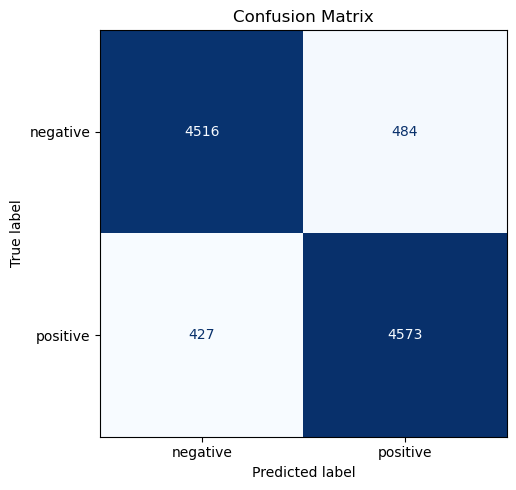

Confusion matrix saved to confusion_matrix.png


In [20]:
def evaluate_model(model, X_test, y_test, label_names=["negative", "positive"]):
    print("\n===== MODEL EVALUATION =====")
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy : {acc * 100:.2f}%")

    # Classification report (precision, recall, F1)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_names))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()
    print("Confusion matrix saved to confusion_matrix.png")

    return y_pred, y_prob

y_pred, y_prob = evaluate_model(model, X_test, y_test)


Top 20 words → POSITIVE sentiment:
  great                          10.6548
  excellent                      10.5256
  perfect                        8.7806
  amazing                        8.2079
  hilarious                      8.0148
  one best                       6.9371
  must see                       6.9041
  wonderful                      6.8754
  superb                         6.6233
  enjoyable                      6.6219
  loved                          6.5877
  brilliant                      6.5479
  enjoyed                        6.3335
  favorite                       6.2523
  well worth                     6.2488
  today                          6.1906
  perfectly                      6.0342
  funniest                       6.0191
  best                           5.8258
  fantastic                      5.7804

Top 20 words → NEGATIVE sentiment:
  worst                          -14.1619
  awful                          -12.8000
  waste                          -11.0795


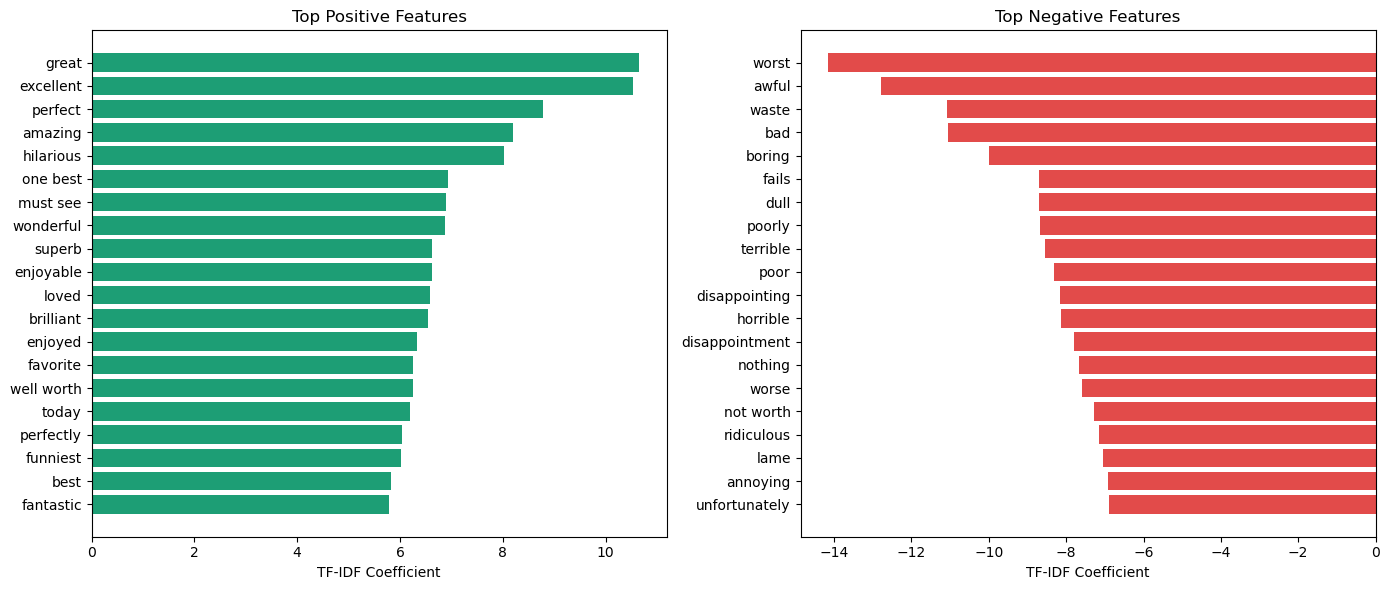

Feature importance chart saved to top_features.png


In [21]:
def show_top_features(model, vectorizer, n=20):
    feature_names = np.array(vectorizer.get_feature_names_out())
    coefs = model.coef_[0]

    top_positive_idx = np.argsort(coefs)[-n:][::-1]
    top_negative_idx = np.argsort(coefs)[:n]

    top_positive_words = feature_names[top_positive_idx]
    top_negative_words = feature_names[top_negative_idx]

    print(f"\nTop {n} words → POSITIVE sentiment:")
    for word, coef in zip(top_positive_words, coefs[top_positive_idx]):
        print(f"  {word:<30} {coef:.4f}")

    print(f"\nTop {n} words → NEGATIVE sentiment:")
    for word, coef in zip(top_negative_words, coefs[top_negative_idx]):
        print(f"  {word:<30} {coef:.4f}")

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.barh(top_positive_words[::-1], coefs[top_positive_idx][::-1], color="#1D9E75")
    ax1.set_title("Top Positive Features")
    ax1.set_xlabel("TF-IDF Coefficient")

    ax2.barh(top_negative_words[::-1], coefs[top_negative_idx][::-1], color="#E24B4A")
    ax2.set_title("Top Negative Features")
    ax2.set_xlabel("TF-IDF Coefficient")

    plt.tight_layout()
    plt.savefig("top_features.png", dpi=150)
    plt.show()
    print("Feature importance chart saved to top_features.png")

show_top_features(model, tfidf)


In [22]:
def predict_sentiment(text: str, model=model, vectorizer=tfidf) -> dict:
    """
    Predict sentiment for a new review string.

    Returns:
        dict with 'label' (positive/negative) and 'confidence' (0–1)
    """
    cleaned  = preprocess_text(text)
    features = vectorizer.transform([cleaned])
    label_id = model.predict(features)[0]
    proba    = model.predict_proba(features)[0]

    label      = "positive" if label_id == 1 else "negative"
    confidence = proba[label_id]

    return {"label": label, "confidence": round(float(confidence), 4)}


# --- Test it ---
sample_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story was gripping.",
    "Terrible film. Boring, predictable, and a complete waste of 2 hours.",
    "It was okay. Not great, not terrible. Some parts were interesting but it dragged on.",
    "I can't believe how bad this was. The worst movie I've seen in years.",
    "A masterpiece of storytelling. Emotionally powerful and visually stunning.",
]

print("\n===== CUSTOM REVIEW PREDICTIONS =====")
for review in sample_reviews:
    result = predict_sentiment(review)
    emoji  = "✅" if result["label"] == "positive" else "❌"
    print(f"\n{emoji} [{result['label'].upper()}] (confidence: {result['confidence']:.2%})")
    print(f"   Review: {review[:80]}...")


===== CUSTOM REVIEW PREDICTIONS =====

✅ [POSITIVE] (confidence: 97.02%)
   Review: This movie was absolutely fantastic! The acting was superb and the story was gri...

❌ [NEGATIVE] (confidence: 99.99%)
   Review: Terrible film. Boring, predictable, and a complete waste of 2 hours....

❌ [NEGATIVE] (confidence: 87.85%)
   Review: It was okay. Not great, not terrible. Some parts were interesting but it dragged...

❌ [NEGATIVE] (confidence: 99.81%)
   Review: I can't believe how bad this was. The worst movie I've seen in years....

✅ [POSITIVE] (confidence: 97.77%)
   Review: A masterpiece of storytelling. Emotionally powerful and visually stunning....


In [23]:
def save_model(model, vectorizer, model_path="sentiment_model.pkl", vec_path="tfidf_vectorizer.pkl"):
    with open(model_path, "wb") as f:
        pickle.dump(model, f)
    with open(vec_path, "wb") as f:
        pickle.dump(vectorizer, f)
    print(f"\nModel saved to {model_path}")
    print(f"Vectorizer saved to {vec_path}")


def load_model(model_path="sentiment_model.pkl", vec_path="tfidf_vectorizer.pkl"):
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    with open(vec_path, "rb") as f:
        vectorizer = pickle.load(f)
    print("Model and vectorizer loaded successfully.")
    return model, vectorizer

save_model(model, tfidf)


Model saved to sentiment_model.pkl
Vectorizer saved to tfidf_vectorizer.pkl
